# 

Limpieza y Preparación de Dataset de Tomate

Proyecto: Agente inteligente para detección de enfermedades del tomate  
Materia: Machine Learning II  
Integrante: Steven  

Objetivo:
Realizar la limpieza, organización y análisis exploratorio de un dataset
de hojas de tomate con distintas enfermedades, dejando los datos listos
para su uso en modelos de aprendizaje automático en futuras fases.

# Importacion de librerias

In [4]:
# Manejo de carpetas y archivos
import os

# Manejo de datos estructurados
import pandas as pd

# Visualización de datos
import matplotlib.pyplot as plt

# Definicion de ruta del data set

In [5]:
DATASET_PATH = "../dataset/raw/augmented_dataset"

# Verificacion de clase de enfermedades 

In [3]:
# Listar las carpetas (clases) del dataset
clases = os.listdir(DATASET_PATH)

print("Clases encontradas:")
for clase in clases:
    print("-", clase)

Clases encontradas:
- Tomato_Bacterial_spot
- Tomato_Early_blight
- Tomato_healthy
- Tomato_Late_blight
- Tomato_Leaf_Mold
- Tomato_Septoria_leaf_spot
- Tomato_Spider_mites_Two_spotted_spider_mite
- Tomato__Target_Spot
- Tomato__Tomato_mosaic_virus
- Tomato__Tomato_YellowLeaf__Curl_Virus


# Contamos datos por clase

In [6]:
# Diccionario para guardar el conteo
conteo_clases = {}

for clase in clases:
    ruta_clase = os.path.join(DATASET_PATH, clase)
    conteo_clases[clase] = len(os.listdir(ruta_clase))

# Mostrar resultados
for clase, cantidad in conteo_clases.items():
    print(f"{clase}: {cantidad} imágenes")

Tomato_Bacterial_spot: 3164 imágenes
Tomato_Early_blight: 2963 imágenes
Tomato_healthy: 3072 imágenes
Tomato_Late_blight: 3106 imágenes
Tomato_Leaf_Mold: 2975 imágenes
Tomato_Septoria_leaf_spot: 3112 imágenes
Tomato_Spider_mites_Two_spotted_spider_mite: 3104 imágenes
Tomato__Target_Spot: 3064 imágenes
Tomato__Tomato_mosaic_virus: 2841 imágenes
Tomato__Tomato_YellowLeaf__Curl_Virus: 3209 imágenes



# Crear dataset tabular (Imagenes → CSV)

In [8]:
# Lista para almacenar los registros
data = []

for clase in clases:
    ruta_clase = os.path.join(DATASET_PATH, clase)
    
    for archivo in os.listdir(ruta_clase):
        ruta_imagen = os.path.join(ruta_clase, archivo)
        
        # Guardamos la ruta de la imagen y su etiqueta
        data.append([ruta_imagen, clase])

# Crear DataFrame
df = pd.DataFrame(data, columns=["ruta_imagen", "enfermedad"])

# Mostrar las primeras filas
df.head()

,ruta_imagen,enfermedad
0,../dataset/raw/augmented_dataset\Tomato_Bacter...,Tomato_Bacterial_spot
1,../dataset/raw/augmented_dataset\Tomato_Bacter...,Tomato_Bacterial_spot
2,../dataset/raw/augmented_dataset\Tomato_Bacter...,Tomato_Bacterial_spot
3,../dataset/raw/augmented_dataset\Tomato_Bacter...,Tomato_Bacterial_spot
4,../dataset/raw/augmented_dataset\Tomato_Bacter...,Tomato_Bacterial_spot


# Verificacion de valores nulos

In [9]:
# Comprobar valores nulos
df.isnull().sum()

ruta_imagen    0
enfermedad     0
dtype: int64

# Eliminar Duplicados

In [10]:
# Eliminar registros duplicados
df = df.drop_duplicates()

print("Total de registros finales:", len(df))

Total de registros finales: 30610


# Analisis Exploratorio (Grafico)

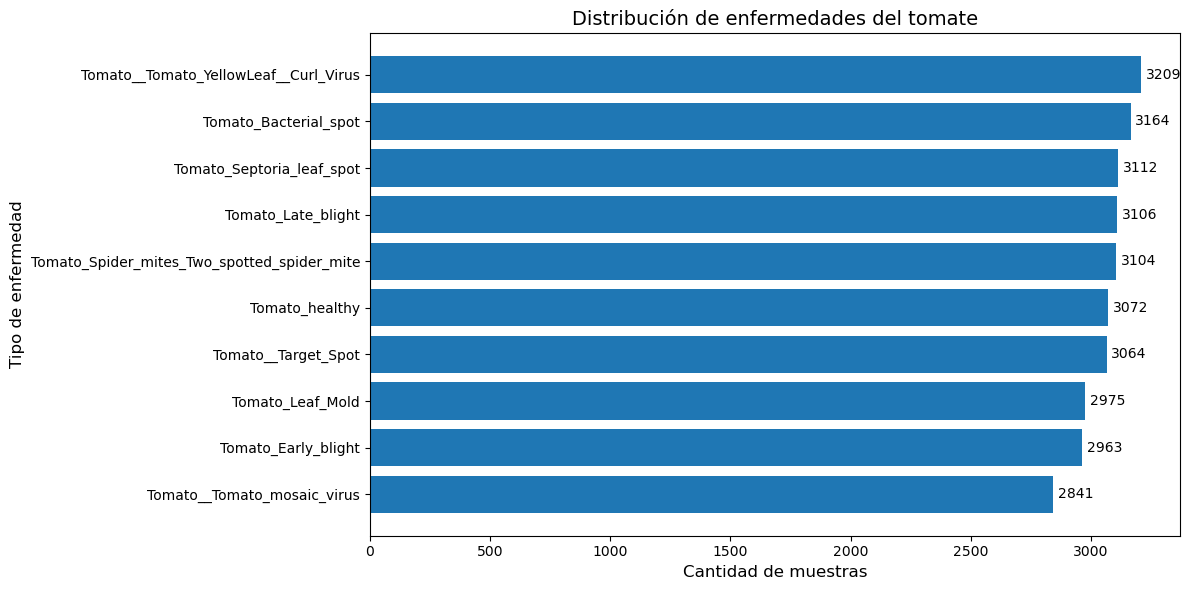

In [13]:
# Conteo de clases
conteo = df["enfermedad"].value_counts().sort_values(ascending=True)

# Crear figura más grande
plt.figure(figsize=(12, 6))

# Gráfico horizontal (MUCHO más legible)
plt.barh(conteo.index, conteo.values)

# Títulos y etiquetas claras
plt.title("Distribución de enfermedades del tomate", fontsize=14)
plt.xlabel("Cantidad de muestras", fontsize=12)
plt.ylabel("Tipo de enfermedad", fontsize=12)

# Mostrar valores sobre las barras
for i, v in enumerate(conteo.values):
    plt.text(v + 20, i, str(v), va='center')

plt.tight_layout()
plt.show()


# Exportar data set limpio

In [ ]:
# Guardar el dataset limpio en processed
df.to_csv("../dataset/processed/dataset_tomate_limpio.csv", index=False)
print("Dataset limpio guardado correctamente.")

# Crear variables numericas

In [14]:
# Crear una serie con el número de muestras por enfermedad
conteo = df["enfermedad"].value_counts()

conteo

enfermedad
Tomato__Tomato_YellowLeaf__Curl_Virus          3209
Tomato_Bacterial_spot                          3164
Tomato_Septoria_leaf_spot                      3112
Tomato_Late_blight                             3106
Tomato_Spider_mites_Two_spotted_spider_mite    3104
Tomato_healthy                                 3072
Tomato__Target_Spot                            3064
Tomato_Leaf_Mold                               2975
Tomato_Early_blight                            2963
Tomato__Tomato_mosaic_virus                    2841
Name: count, dtype: int64

# Histograma (El comportamiento de los datos)

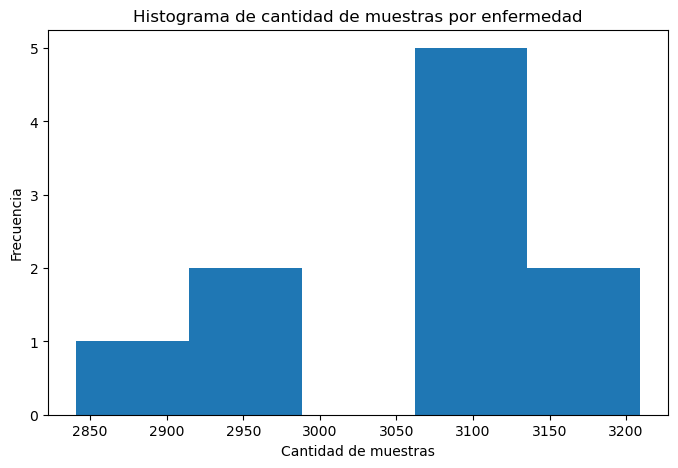

In [18]:
plt.figure(figsize=(8,5))

plt.hist(conteo.values, bins=5)

plt.title("Histograma de cantidad de muestras por enfermedad")
plt.xlabel("Cantidad de muestras")
plt.ylabel("Frecuencia")

plt.show()

# Calculo de varianza

In [20]:

varianza = conteo.var()

print("Varianza del número de muestras:", varianza)

Varianza del número de muestras: 11613.111111111111


# Desviacion Estandar 

In [19]:
# Calcular desviación estándar
desviacion = conteo.std()

print("Desviación estándar:", desviacion)

Desviación estándar: 107.7641457587407


## Interpretación estadística

El análisis estadístico muestra que la varianza y la desviación estándar
de la cantidad de muestras por enfermedad son relativamente bajas,
lo que indica que el dataset se encuentra balanceado.  
Esto es favorable para el entrenamiento de modelos de aprendizaje automático,
ya que reduce el sesgo hacia una clase específica.